Zdrowy obraz i chory obraz zostały znalezione!
Zdrowy obraz zapisany jako healthy_image.png
Chory obraz zapisany jako sick_image.png


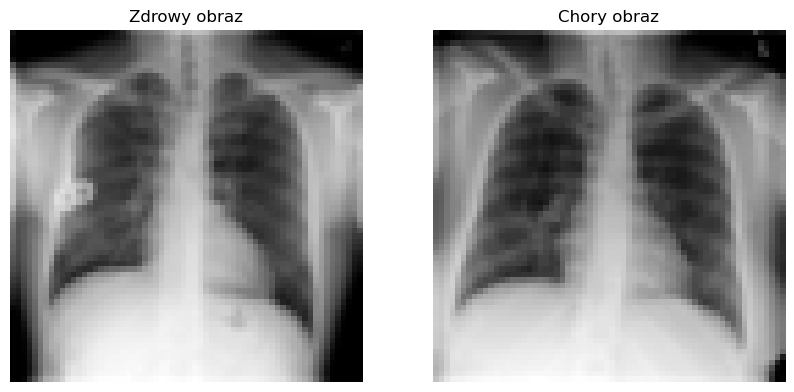

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
from cnn import ChestMNISTDataset
import os

#  Funkcja do znalezienia zdrowego i chorego obrazu
def find_healthy_and_sick_images(dataset):
    healthy_image, sick_image = None, None

    for idx in range(len(dataset)):
        image, label = dataset[idx]  # Pobierz obraz i etykietę

        # Sprawdź, czy to obraz zdrowy (wszystkie etykiety = 0)
        if np.all(label == 0) and healthy_image is None:
            healthy_image = image

        # Sprawdź, czy to obraz chory (przynajmniej jedna etykieta = 1)
        elif np.any(label == 1) and sick_image is None:
            sick_image = image

        # Przerwij pętlę, jeśli oba obrazy zostały znalezione
        if healthy_image is not None and sick_image is not None:
            break

    return healthy_image, sick_image

# Przykład użycia
# Wczytaj dane (zmień ścieżkę na odpowiedni plik .npz)
npz_file = "data/chestmnist_test_64x64.npz"  # Zamień na rzeczywistą ścieżkę
dataset = ChestMNISTDataset(npz_file)

# Znajdź zdrowy i chory obraz
healthy_image, sick_image = find_healthy_and_sick_images(dataset)

# Sprawdź, czy obrazy zostały znalezione
if healthy_image is not None and sick_image is not None:
    print("Zdrowy obraz i chory obraz zostały znalezione!")
else:
    print("Nie znaleziono zdrowego lub chorego obrazu w datasetcie.")

# Utwórz katalog do zapisywania obrazów
output_dir = "output_images"
os.makedirs(output_dir, exist_ok=True)

# Zapisz obrazy na dysk
if healthy_image is not None:
    healthy_image.save(os.path.join(output_dir, "healthy_image.jpg"))
    print("Zdrowy obraz zapisany jako healthy_image.png")

if sick_image is not None:
    sick_image.save(os.path.join(output_dir, "sick_image.jpg"))
    print("Chory obraz zapisany jako sick_image.png")

# Wyświetl obrazy
plt.figure(figsize=(10, 5))

if healthy_image is not None:

    plt.subplot(1, 2, 1)
    plt.imshow(np.array(healthy_image), cmap="gray")
    plt.title("Zdrowy obraz")
    plt.axis("off")

if sick_image is not None:
    plt.subplot(1, 2, 2)
    plt.imshow(np.array(sick_image), cmap="gray")
    plt.title("Chory obraz")
    plt.axis("off")

plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from captum.attr import GuidedGradCam
from captum.attr import visualization as viz
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from PIL import Image
import numpy as np
from cnn import CNN


# Przygotuj transformacje dla obrazów
transform = Compose([
    Resize((64, 64)),        # Rozmiar obrazu ChestMNIST
    ToTensor(),              # Konwersja do tensora
    Normalize(mean=[0.5], std=[0.5])  # Normalizacja dla obrazów w skali szarości
])

# Funkcja do wczytania pojedynczego obrazu z dysku
def load_image(image_path):
    image = Image.open(image_path).convert("L")  # W skali szarości
    image = transform(image).unsqueeze(0)       # Dodaj wymiar batch
    return image


# Ścieżka do zdrowego i chorego obrazu
healthy_image_path = "output_images/healthy_image.jpg"
sick_image_path = "output_images/sick_image.jpg"

# Wczytaj obrazy
healthy_image = load_image(healthy_image_path)
sick_image = load_image(sick_image_path)

# Załaduj model i przenieś na urządzenie
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=14).to(device)  # Liczba klas w ChestMNIST
model.load_state_dict(torch.load("best_model.pth"))  # Załaduj wytrenowany model
model.eval()

# Wybierz warstwę do analizy (ostatnia warstwa konwolucyjna)
target_layer = model.conv3

# Utwórz obiekt GuidedGradCam
guided_gc = GuidedGradCam(model, target_layer)

# Oblicz Grad-CAM dla zdrowego obrazu
healthy_attributions = guided_gc.attribute(healthy_image.to(device), target=0)  # Klasa zdrowa (np. indeks 0)

# Oblicz Grad-CAM dla chorego obrazu
sick_attributions = guided_gc.attribute(sick_image.to(device), target=1)  # Klasa chora (np. indeks 1)

# Funkcja do wizualizacji Grad-CAM
# Funkcja do wizualizacji Grad-CAM z obsługą zerowych map
def visualize_grad_cam(image, attributions, title, save_path):
    attr = attributions.squeeze(0).cpu().detach().numpy()

    print(attr)
    
    # Sprawdź, czy wszystkie wartości są zerowe
    if np.all(attr == 0):
        print(f"Mapa Grad-CAM dla '{title}' zawiera same zera. Pomijam wizualizację.")
        return
    
    # Wizualizacja mapy Grad-CAM
    viz.visualize_image_attr(
        attr,
        method="heat_map",
        sign="positive",
        show_colorbar=True,
        title=title
    )
    plt.savefig(save_path)
    plt.close()


# Wizualizuj i zapisz Grad-CAM dla zdrowego obrazu
visualize_grad_cam(
    healthy_image,
    healthy_attributions,
    title="Grad-CAM: Zdrowy",
    save_path="grad_cam_healthy.png"
)

# Wizualizuj i zapisz Grad-CAM dla chorego obrazu
visualize_grad_cam(
    sick_image,
    sick_attributions,
    title="Grad-CAM: Chory",
    save_path="grad_cam_sick.png"
)

print("Grad-CAM dla zdrowego i chorego obrazu zostały zapisane jako 'grad_cam_healthy.png' i 'grad_cam_sick.png'.")


c:\Users\mkowalik\AppData\Local\anaconda3\envs\cnn-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[[[-0. -0. -0. ... -0. -0. -0.]
  [ 0. -0.  0. ...  0.  0. -0.]
  [-0.  0. -0. ... -0. -0. -0.]
  ...
  [-0.  0. -0. ... -0.  0. -0.]
  [-0. -0.  0. ... -0.  0. -0.]
  [-0. -0. -0. ... -0. -0. -0.]]]
Mapa Grad-CAM dla 'Grad-CAM: Zdrowy' zawiera same zera. Pomijam wizualizację.
[[[-0. -0. -0. ... -0. -0. -0.]
  [-0.  0. -0. ...  0. -0. -0.]
  [-0. -0. -0. ... -0.  0.  0.]
  ...
  [-0. -0. -0. ...  0. -0. -0.]
  [ 0. -0.  0. ... -0.  0. -0.]
  [ 0.  0.  0. ... -0. -0. -0.]]]
Mapa Grad-CAM dla 'Grad-CAM: Chory' zawiera same zera. Pomijam wizualizację.
Grad-CAM dla zdrowego i chorego obrazu zostały zapisane jako 'grad_cam_healthy.png' i 'grad_cam_sick.png'.


C:\Users\mkowalik\AppData\Local\Temp\ipykernel_27776\222271593.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))  # Za